# Grain strucrture analysis

### Import modules
Import necessary libraries for grain structure analysis:
- `mcgs`: Monte Carlo grain structure simulation
- `gsan2d`: 2D grain structure analysis module
- `seaborn`, `pandas`, `numpy`, `matplotlib`: Data manipulation and visualization

In [1]:
from upxo.ggrowth.mcgs import mcgs
from upxo.analysis.analysis2d import gsan2d
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


### Spawn a temporal grasin structue dataset
Create a Monte Carlo grain structure simulation object using the input dashboard configuration file. Execute the simulation and detect grain structures in the resulting microstructure for temporal analysis.

In [2]:
pxt = mcgs(input_dashboard='C:\\Development\\UPXO\\upxo_library\\src\\upxo\\interfaces\\user_inputs\\input_dashboard_profiling_alg202a.xls')
pxt.simulate()
pxt.detect_grains()

C:\Development\UPXO\upxo_library\src\upxo\interfaces\user_inputs
C:\Development\UPXO\upxo_library\src\upxo\interfaces\user_inputs\input_dashboard_profiling_alg202a.xls
Algo_hops details
(('200.0', 100),)
[False]





 Initiating Monte-Carlo simulation
     xmin, xmax, xinc: 0.0, 100.0, 1.0
     ymin, ymax, yinc: 0.0, 100.0, 1.0
     zmin, zmax, zinc: 0.0, 1000.0, 1.0
     No. of states: 5
     Dimensionality: 2
     Algorithm: 200.0 





-----------------------
[1. 1. 1.]
[1. 1. 1.]
[1. 1. 1.]
-----------------------
########################################
200.0
########################################
Using ALG-200: SA's SL NL-1 TP1 C2 unweighted Q-Pott's model:
|--------------- MC SIM RUN IN PROGRESS on: ALG200---------------|
GS temporal slice 0 stored
 ..............................
GS temporal slice 1 stored
 ..............................
GS temporal slice 2 stored
 ..............................
GS temporal slice 3 stored
 ..............................
GS temporal slice 4 sto

### Port the dataset into grain structure analysis module

Create a `gsan2d` object from the Monte Carlo grain structure temporal stack (`pxt`). This initializes the analysis framework with specific characterization parameters:
- Enabled features: `aspect_ratio`, `solidity`, `eccentricity`, `euler_number`, `moments_hu`, `get_grain_coords`
- Disabled features: neighbor detection (performed separately), grain boundary characterization, morphological properties
- The object processes all temporal slices from the simulation for subsequent analysis

In [3]:
gsan = gsan2d.from_gsstack_temporal(pxt, detect_grains=False, gsids=[], ispxtal=True, prechar=False, 
                                    find_neigh=False,
                                    npixels=False, npixels_gb=False, gb_length_px=False,
                                    eq_diameter=False, feret_diameter=False,
                                    perimeter=False, perimeter_crofton=False, aspect_ratio=True,
                                    compactness=False, solidity=True, morph_ori=False,
                                    circularity=False, eccentricity=True,
                                    euler_number=True, moments_hu=True,
                                    char_gb=False, get_grain_coords=True)

 Characterizing grain structure slice 0 
Extracting requested GS props across all available states
--------State value: 5 of 5
----------------------------------------
 Characterizing grain structure slice 1 
Extracting requested GS props across all available states
--------State value: 5 of 5
----------------------------------------
 Characterizing grain structure slice 2 
Extracting requested GS props across all available states
--------State value: 5 of 5
----------------------------------------
 Characterizing grain structure slice 3 
Extracting requested GS props across all available states
--------State value: 5 of 5
----------------------------------------
 Characterizing grain structure slice 4 
Extracting requested GS props across all available states
--------State value: 5 of 5
----------------------------------------
 Characterizing grain structure slice 5 
Extracting requested GS props across all available states
--------State value: 5 of 5
---------------------------------

### view all grain structure ids.
View the grain structure IDs (gsids) available in the analysis object and verify they match the keys from the original Monte Carlo simulation dataset.

    Note: the gsidds will be same as keys in pxt.gs dataset

In [4]:
print(gsan.gsid)
print(pxt.gs.keys())

[0, 1, 2, 3, 4, 5, 6]
dict_keys([0, 1, 2, 3, 4, 5, 6])


### View the neighbour diictionary
This is expected to be empty, as neighbourhood data has'nt yet been computed

In [5]:
print(gsan.gsstack[5].neigh_gid)

None


### Create the neighbour dictionaries across all temporal slices

Compute neighbor relationships for grains in each temporal slice of the grain structure dataset.

    Note: Due to a NUMBA-related kernel crash when calling `gsan.find_neigh(gsids=None)` in Jupyter notebook, we implement a workaround by iterating through each grain structure ID (gsid) and calling `find_neigh()` individually using native python method implementation. This populates the `neigh_gid` dictionary for each temporal slice, enabling subsequent neighbor count analysis and distribution characterization.

In [6]:
# gsan.find_neigh(gsids=None) # <-- NUMBA CRASHES JUPYTER KERNEL IF CALLED HERE.
# Instead, use below cell, manually calling the function after creation of gsan object.

In [7]:
# Mitigating numba crash by calling the function for each gsid separately.
for gsid in gsan.gsstack.keys():
    gsan.gsstack[gsid].find_neigh()


Extracting neigh list for all grains


Extracting neigh list for all grains


Extracting neigh list for all grains


Extracting neigh list for all grains


Extracting neigh list for all grains


Extracting neigh list for all grains


Extracting neigh list for all grains



In [8]:
"""
NUMBA CALL -- CRASHING AT THE MOMENT. Under investigation.
for gsid in gsan.gsstack.keys():
    gstslice = gsan.gsstack[gsid]
    gstslice.find_neigh_v2(p=1.0, include_central_grain=False,
                           throw_numba_dict=False, verbosity_nfids=1000)
"""

'\nNUMBA CALL -- CRASHING AT THE MOMENT. Under investigation.\nfor gsid in gsan.gsstack.keys():\n    gstslice = gsan.gsstack[gsid]\n    gstslice.find_neigh_v2(p=1.0, include_central_grain=False,\n                           throw_numba_dict=False, verbosity_nfids=1000)\n'

### Neighbour grain count distributions - temporal evolution
Analyze how the neighbor count distributions change across different Monte-Carlo simulation steps (temporal slices). The following visualizations provide insights into the grain structure evolution:

- **Cumulative histogram**: Shows the distribution of neighbor counts across all grains at each time step
- **Density plots (KDE)**: Reveals the probability density of neighbor counts, highlighting the most common coordination numbers
- **Maximum neighbor count evolution**: Tracks the grain with the highest number of neighbors at each MC step

Lets see how the neighbour count distributions evolved over Monte-Carlo time. This could be used to:
1. characterize a 2D / 3D MC algorithm
2. relatuve study of 3D neighbour structure vs 2D slice neighbour structure

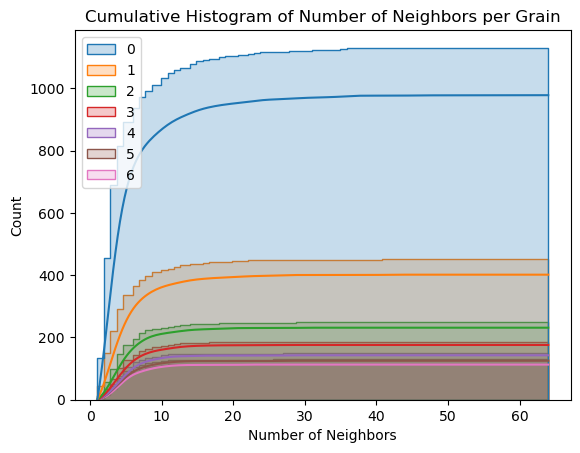

In [9]:
neigh_counts = {gsid: [len(n) for n in gsan.gsstack[gsid].neigh_gid.values()] for gsid in gsan.gsstack.keys()}
neigh_counts_df = pd.DataFrame(dict([(k, pd.Series(v)) for k, v in neigh_counts.items()]))
sns.histplot(data=neigh_counts_df, kde=True, cumulative=True, element='step')
plt.xlabel('Number of Neighbors')
plt.ylabel('Count')
plt.title('Cumulative Histogram of Number of Neighbors per Grain')
plt.show()

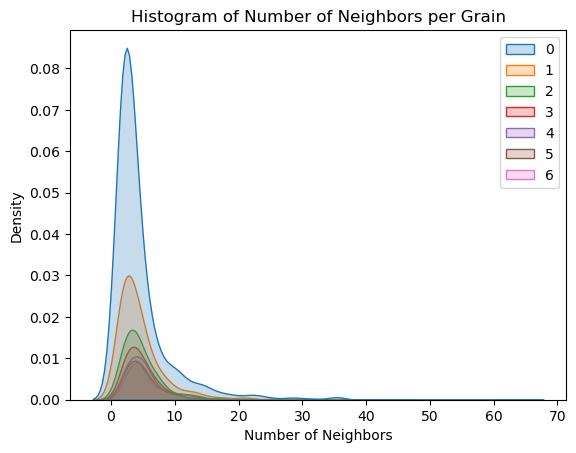

In [10]:
neigh_counts = {gsid: [len(n) for n in gsan.gsstack[gsid].neigh_gid.values()] for gsid in gsan.gsstack.keys()}
neigh_counts_df = pd.DataFrame(dict([(k, pd.Series(v)) for k, v in neigh_counts.items()]))
sns.kdeplot(data=neigh_counts_df, fill=True)
plt.xlabel('Number of Neighbors')
plt.ylabel('Density')
plt.title('Histogram of Number of Neighbors per Grain')
plt.show()

### Temporal evolution of maxuimum number of neighbouring grains (featurezas)

Track the evolution of the maximum neighbor count across Monte-Carlo simulation steps. This metric captures the grain with the highest coordination number (most neighbors) at each temporal slice.

**Why the maximum neighbor count decreases:**
- As the Monte Carlo grain growth simulation progresses, smaller grains are consumed by larger grains through grain boundary migration
- The microstructure coarsens, resulting in fewer total grains with larger average sizes
- High-coordination grains (with many small neighbors) preferentially eliminate these small neighbors
- The topology evolves toward a more stable, lower-energy configuration with reduced coordination numbers
- This reflects the physical principle that grain growth reduces interfacial energy by minimizing grain boundary area

**Scientific applications:**
1. **Algorithm validation**: Compare 2D section statistics against 3D bulk properties to validate Monte Carlo algorithm accuracy
2. **Kinetic characterization**: Quantify the rate of topological simplification during grain coarsening
3. **Microstructure stability assessment**: Identify when the structure approaches a quasi-steady-state topology
4. **Cross-sectioning effects**: Study how 2D slice neighbor distributions differ from true 3D neighbor networks
5. **Grain growth law verification**: Correlate maximum coordination decay with classical grain growth exponents
6. **Process optimization**: Determine optimal annealing times for desired grain size distributions

Text(0.5, 1.0, 'Maximum Neighbour Count per Grain vs Monte-Carlo Step')

<Figure size 1000x600 with 0 Axes>

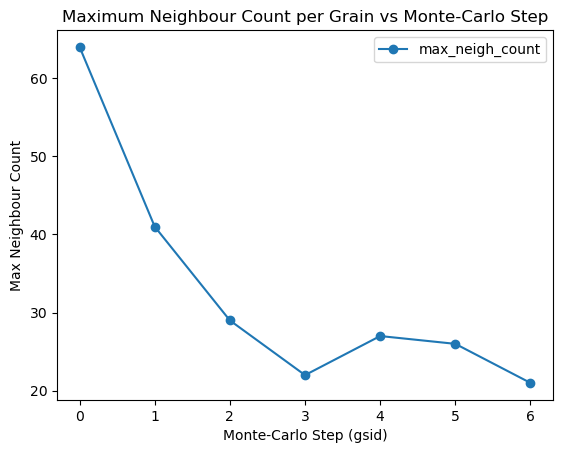

In [11]:
neigh_counts_max = {gsid: max([len(n) for n in gsan.gsstack[gsid].neigh_gid.values()]) for gsid in gsan.gsstack.keys()}
neigh_counts_max_df = pd.DataFrame.from_dict(neigh_counts_max, orient='index', columns=['max_neigh_count'])
plt.figure(figsize=(10,6))
neigh_counts_max_df.plot(marker='o')
plt.xlabel('Monte-Carlo Step (gsid)')
plt.ylabel('Max Neighbour Count')
plt.title('Maximum Neighbour Count per Grain vs Monte-Carlo Step')